# NEW SYSTEM

In [1]:
user = r"\SagixOffice"  # HomeOffice
#user = r"\vie43sq"  # University
import sys
sys.path.append(rf"C:\Users{user}\OneDrive - Universität Würzburg\GitHub\Photoswitching")

import src.NEW_transitions as tr
import src.NEW_fluorophores as fl
import src.NEW_simulation as si
import src.NEW_photophysics as ph

import numpy as np

%load_ext autoreload
%autoreload 2

C:\Users\SagixOffice\miniconda3\envs\MarkovModels\lib\site-packages\pycorrelate\pycorrelate.py:118: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def ucorrelate(t, u, maxlag=None):


### Setup the fluorophores

In [2]:
fl_1 = fl.Fluorophore(name='Cy5', position=np.array([0, 0]))
fl_2 = fl.Fluorophore(name='Cy5', position=np.array([1.5, 1]))
fl_3 = fl.Fluorophore(name='Cy5', position=np.array([3, 4]))

fl_set = fl.FluorophoreSystem(fluorophores=[fl_1, fl_2, fl_3])

### Setup the transitions

In [3]:
excitation = tr.Transition(rate=40, transition_type=tr.TransitionType.EXCITATION)
fluorescence = tr.Transition(rate=0.01, transition_type=tr.TransitionType.FLUORESCENT_EMISSION)
# h_frets = tr.energy_transfer_rates(transition_type=tr.TransitionType.HOMO_FRET, 
#                                    distances=fl_set.distances, rates=[1, 2, 3])

transitions = [excitation, fluorescence]

tr_set = tr.TransitionSet(transitions)

### Setup the summarizing object

In [5]:
system = ph.PhotophysicsMC(fl_set, tr_set)

(<Figure size 640x480 with 1 Axes>, <AxesSubplot:>)

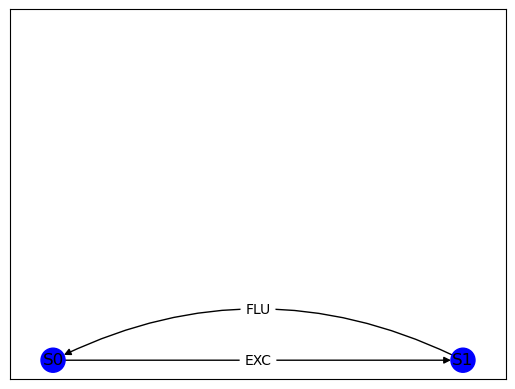

In [6]:
system.transitions.plot()

In [7]:
system.finalize_transitions()

In [8]:
system.predict()

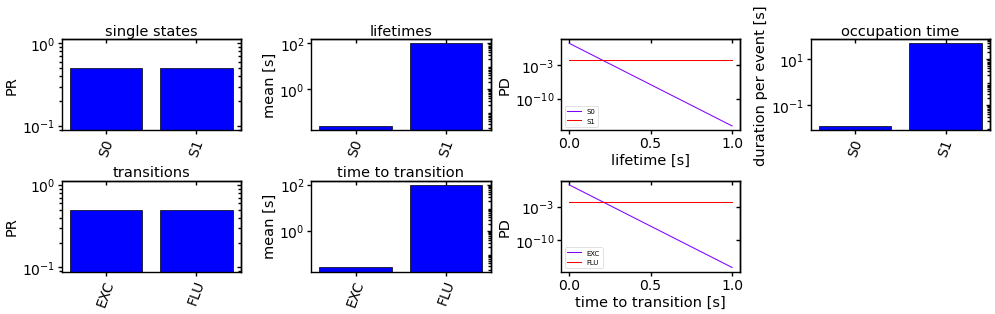

In [9]:
system.statistics.prediction.plot_all(transitions=system.transitions)

In [10]:
system.simulate(start_at=(0, 0, 0), size=10000, end_time=None, seed=100)

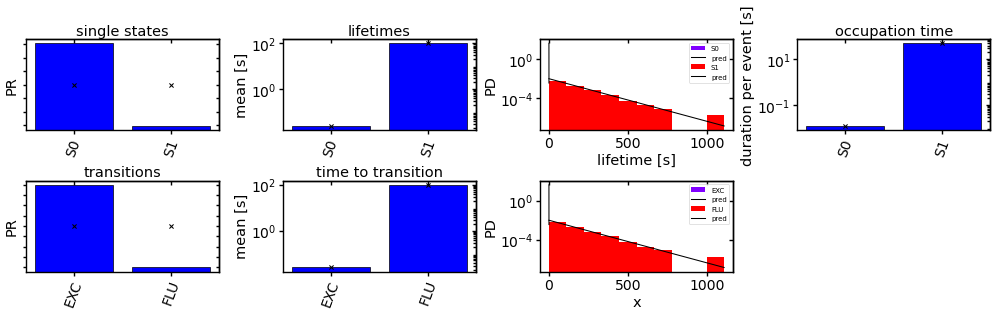

In [11]:
system.statistics.analysis.plot_all(transitions=system.transitions, prediction=system.statistics.prediction)

In [12]:
system.fetch_emissions(1, '4ms', 10, 10)

(<Figure size 600x300 with 1 Axes>,
 array([[<AxesSubplot:title={'center':'intensity distribution'}, xlabel='photon count', ylabel='PD'>]],
       dtype=object))

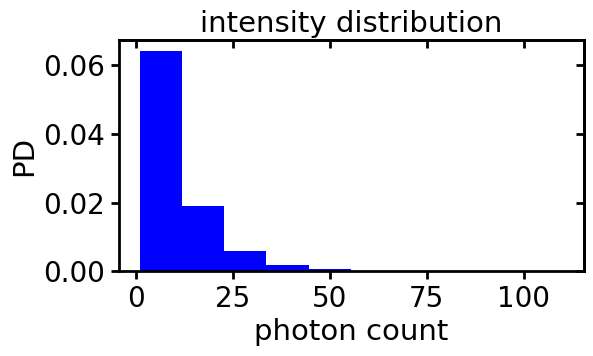

In [13]:
system.emissions.plot(mode='histogram')

(<Figure size 600x300 with 1 Axes>,
 array([[<AxesSubplot:title={'center':'fluorescence trajectory'}, xlabel='time [s]', ylabel='photon count'>]],
       dtype=object))

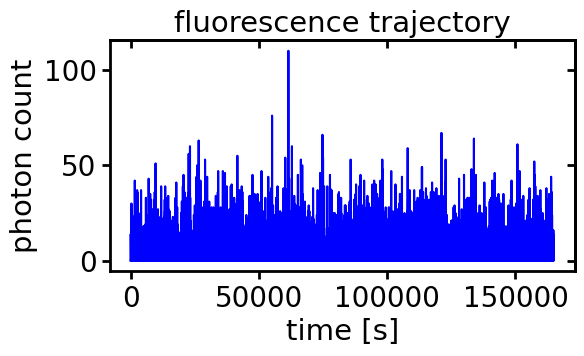

In [14]:
system.emissions.plot(mode='')

In [27]:
system.perform_FCS(exp_min=-3, exp_max=4)

In [28]:
system.fcs.tau

array([1.38913971e-03, 2.47027854e-03, 4.39284546e-03, 7.81170663e-03,
       1.38913971e-02, 2.47027854e-02, 4.39284546e-02, 7.81170663e-02,
       1.38913971e-01, 2.47027854e-01, 4.39284546e-01, 7.81170663e-01,
       1.38913971e+00, 2.47027854e+00, 4.39284546e+00, 7.81170663e+00,
       1.38913971e+01, 2.47027854e+01, 4.39284546e+01, 7.81170663e+01,
       1.38913971e+02, 2.47027854e+02, 4.39284546e+02, 7.81170663e+02,
       1.38913971e+03, 2.47027854e+03, 4.39284546e+03, 7.81170663e+03])

(<Figure size 600x300 with 1 Axes>,
 array([[<AxesSubplot:title={'center':'$\\tau_{min} = 1.39e-03$ s'}, xlabel='$\\tau [s]$', ylabel='$G(\\tau)$'>]],
       dtype=object))

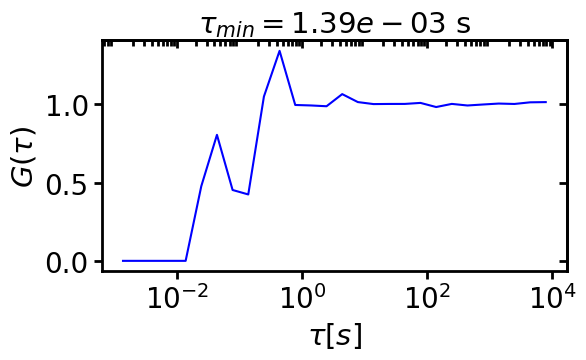

In [29]:
system.fcs.plot()